In [1]:
# Imports and paths
from pathlib import Path
import importlib.util
import geopandas as gpd
import pandas as pd
from scipy.spatial import Voronoi
import numpy as np
from shapely.geometry import Polygon, Point
# from shapely.ops import nearest_points
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import re
import sys
import networkx as nx


In [4]:


# Add working directory to system path
cwd_path = Path.cwd()   
repo_path = cwd_path.parent

# #add src path to system path
# src_path = repo_path / 'src'
# if str(src_path) not in sys.path:
#     sys.path.append(str(src_path))

# if str(repo_path) not in sys.path:
#     sys.path.append(0, str(repo_path))
# else:
#     sys.path.remove(str(repo_path))
#     sys.path.insert(0, str(repo_path))


In [5]:
spec = importlib.util.spec_from_file_location("config", str(repo_path / "config.py"))
config = importlib.util.module_from_spec(spec)
spec.loader.exec_module(config)

data_paths = config.data_paths
miraca_colors = config.miraca_colors


In [ ]:
# Change data paths by editting/running config.py
print("Available data paths:")
for key, path in data_paths.items():
    print(f"  {key}: {path}")

root_dir = Path(r"C:\Users\peregrin\OneDrive - Stichting Deltares\Documents\PhD Daniel Shared\Papers\Paper 3 - Interdependence\from_lieke")
assert root_dir.exists()

Available data paths:
  base_data_path: C:\data
  high_tension_stations: C:\data\raw\StedinData\Hoogspanningsstations\Hoogspanningsstations.shp
  high_tension_network: C:\data\raw\StedinData\Hoogspanningsverbindingen\Hoogspanningsverbindingen.shp
  mid_tension_stations: C:\data\raw\StedinData\Middenspanningsstations\Middenspanningsstations.shp
  mid_tension_network: C:\data\raw\StedinData\Middenspanningsverbindingen\Middenspanningsverbindingen.shp
  mid_low_tension_stations: C:\data\raw\StedinData\MiddenLaagspanningsstations\MiddenLaagspanningsstations.shp
  low_tension_stations: C:\data\raw\StedinData\Laagspanningsstations\Laagspanningsstations.shp
  low_tension_network: C:\data\raw\StedinData\Laagspanningsverbindingen\Laagspanningsverbindingen.shp
  telecom_c2000_masts: C:\data\raw\TelecomData\c2000masten.geojson


In [7]:
# Function definitions
def extract_attr_from_other_tags(tags, attribute):
    """
    Extracts the value of a specific attribute from the 'other_tags' column. The 'other_tags' column contains a string of key-value pairs separated by commas.
    Each key-value pair is in the format 'key=>value'. This function uses a regular expression to find the value associated with the specified attribute.

    Args:
        tags (str): The string containing key-value pairs.
        attribute (str): The attribute whose value we want to extract.

    Returns:
        str or None: The value associated with the specified attribute, or None if not found.

    Example:
        tags = '"tower:type"=>"communication", "height"=>"50", "technology"=>"4G"'
        attribute = 'height'
        extract_attr_from_other_tags(tags, attribute)  # Returns '50'

        use: gdf[attribute] = gdf['other_tags'].apply(lambda tags: extract_attr_from_other_tags(tags, attribute))
    """

    if pd.isna(tags):
        return None
    pattern = fr'"{attribute}"=>"([^"]+)"'
    match = re.search(pattern, tags)
    return match.group(1) if match else None

def drop_features_with_tags(gdf, tags):
    """
    Drops features from the GeoDataFrame that contain specific tags in the 'other_tags' column.

    Args:
        gdf (GeoDataFrame): The input GeoDataFrame.
        tags (list): A list of tags to check for in the 'other_tags' column.

    Returns:
        GeoDataFrame: A new GeoDataFrame with the specified features dropped.

    use: gdf_masked = drop_features_with_tags(gdf, ['power', 'waste', 'gas'])
    """
    mask = gdf['other_tags'].str.contains('|'.join(tags), na=False)
    return gdf[~mask] 

def explore_data_values(gdf, key, value=None):
    """
    Function to explore the data values for a specific key in a GeoDataFrame.
    If value is provided, it filters the GeoDataFrame for that value.
    """
    if value:
        filtered_gdf = gdf[gdf[key] == value]
        print(f"Number of records with {key} = {value}: {len(filtered_gdf)}")
        return filtered_gdf
    else:
        unique_values = gdf[key].unique()
        print(f"Unique values for {key}: {unique_values}")
        return unique_values
    

def create_voronoi_coverage(gdf, hull_buffer=0.01, buffer_scale=0.1, polygon_col='voronoi_polygon', verbose=False):
    """
    Create Voronoi polygons for points in a GeoDataFrame with fallback buffers for edge cases.

    Parameters:
    -----------
    gdf : GeoDataFrame
        Input GeoDataFrame with point geometries
    hull_buffer : float, default 0.1
        Buffer distance for convex hull to handle boundary issues
    buffer_scale : float, default 1.0
        Scale factor for buffer radius (relative to sqrt of average Voronoi area)
    polygon_col : str, default 'voronoi_polygon'
        Name of column to store the resulting polygons
    verbose : bool, default True
        Whether to print warnings and statistics

    Returns:
    --------
    tuple : (gdf_with_polygons, buffer_indices, voronoi_gdf)
        - gdf_with_polygons: Original GDF with polygon column added
        - buffer_indices: List of indices that got buffer polygons instead of Voronoi
        - voronoi_gdf: GeoDataFrame of valid Voronoi polygons for visualization
    """
    points = np.array([[geom.x, geom.y] for geom in gdf.geometry])
    hull = gdf.geometry.union_all().convex_hull.buffer(hull_buffer)
    vor = Voronoi(points)

    valid_regions = [region for region in vor.regions if not -1 in region and len(region) > 0]
    avg_area = np.mean([Polygon([vor.vertices[i] for i in region]).area for region in valid_regions])
    buffer_radius = np.sqrt(avg_area/np.pi) * buffer_scale

    result_gdf = gdf.copy()
    result_gdf[polygon_col] = None
    buffer_indices = []

    for point_idx in range(len(points)):
        region_idx = vor.point_region[point_idx]
        region = vor.regions[region_idx]

        if not -1 in region and len(region) > 0:
            polygon = Polygon([vor.vertices[i] for i in region])
            if polygon.intersects(hull):
                polygon = polygon.intersection(hull)
            result_gdf.at[point_idx, polygon_col] = polygon
        else:
            if verbose:
                print(f'Warning! Point {point_idx} does not have a valid Voronoi region.')
            point = Point(points[point_idx])
            result_gdf.at[point_idx, polygon_col] = point.buffer(buffer_radius)
            buffer_indices.append(point_idx)

    voronoi_polygons = []
    for region in valid_regions:
        polygon = Polygon([vor.vertices[i] for i in region])
        if polygon.intersects(hull):
            voronoi_polygons.append(polygon.intersection(hull))

    voronoi_gdf = gpd.GeoDataFrame(geometry=voronoi_polygons, crs=gdf.crs)

    if verbose:
        missing_count = result_gdf[result_gdf[polygon_col].isnull()].shape[0]
        print(f"Number of points without associated polygons: {missing_count}")
        print(f"Points with buffer polygons: {len(buffer_indices)}")
        print(f"Points with Voronoi polygons: {len(result_gdf) - len(buffer_indices)}")

    return result_gdf, buffer_indices, voronoi_gdf

def plot_voronoi_coverage(gdf, buffer_indices, polygon_col='voronoi_polygon', 
                         figsize=(6, 5), title='Voronoi Polygons vs Buffer Polygons'):
    """
    Plot Voronoi polygons and buffer polygons with different colors.

    Parameters:
    -----------
    gdf : GeoDataFrame
        GeoDataFrame with polygon column
    buffer_indices : list
        Indices of points that got buffer polygons
    polygon_col : str
        Name of polygon column
    figsize : tuple
        Figure size
    title : str
        Plot title
    """
    buffer_gdf = gdf.loc[buffer_indices].copy().set_geometry(polygon_col)
    voronoi_gdf = gdf.drop(buffer_indices).copy().set_geometry(polygon_col)

    fig, ax = plt.subplots(figsize=figsize)
    voronoi_gdf.plot(ax=ax, color='lightblue', alpha=0.6, edgecolor='blue', linewidth=0.5, label='Voronoi Polygons')
    buffer_gdf.plot(ax=ax, color='lightcoral', alpha=0.7, edgecolor='red', linewidth=1, label='Buffer Polygons')
    gdf.plot(ax=ax, color='black', markersize=5, label='Masts')

    # Add custom legend using proxy artists to avoid PatchCollection warning
    legend_handles = [
        Patch(facecolor='lightblue', edgecolor='blue', label='Voronoi Polygons', alpha=0.6),
        Patch(facecolor='lightcoral', edgecolor='red', label='Buffer Polygons', alpha=0.7),
    ]
    ax.legend(handles=legend_handles, loc='upper right', fontsize=10)


    ax.set_title(title, fontsize=14)
    
    plt.tight_layout()
    plt.show()

    return buffer_gdf, voronoi_gdf

def load_electrical_network_data(stations=True, network=True):
    """
    Load all electrical network shapefiles.
    Parameters:
        stations (bool): Whether to load station data
        network (bool): Whether to load network data
    
    Returns:
        dict: Dictionary containing all loaded GeoDataFrames
    """
    electrical_data = {}
    
    # Define the electrical network layers to load
    electrical_layers = {
        'high_tension_stations': 'High Tension Stations',
        'high_tension_network': 'High Tension Network',
        'mid_tension_stations': 'Mid Tension Stations', 
        'mid_tension_network': 'Mid Tension Network',
        'mid_low_tension_stations': 'Mid-Low Tension Stations',
        'low_tension_stations': 'Low Tension Stations',
        'low_tension_network': 'Low Tension Network'
    }
    
    print("--Loading electrical network data...")
    numbering=0
    for key, description in electrical_layers.items():
        if not (stations and 'stations' in key) and not (network and 'network' in key):
            continue
        numbering += 1
        print(f"{numbering}. {key} - {description}")

        if key in data_paths:
            file_path = data_paths[key]
            try:
                print(f"  Loading {description}...")
                gdf = gpd.read_file(file_path).to_crs(epsg=4326)
                electrical_data[key] = gdf
                print(f"Loaded {len(gdf)} features")
            except Exception as e:
                print(f"Failed to load {description}: {e}")
        else:
            print(f"Path for {description} not found in config")
    
    return electrical_data

def load_telecom_data():
    """
    Load telecom data from the centralized config.
    
    Returns:
        dict: Dictionary containing telecom GeoDataFrames
    """
    telecom_data = {}
    
    print("--Loading telecom data...")
    if 'telecom_c2000_masts' in data_paths:
        try:
            print("  Loading C2000 masts...")
            gdf = gpd.read_file(data_paths['telecom_c2000_masts']).to_crs(epsg=4326)
            gdf['id'] = gdf.index.astype(str)  # Add unique ID
            telecom_data['c2000_masts'] = gdf
            print(f"Loaded {len(gdf)} C2000 masts")
        except Exception as e:
            print(f"Failed to load C2000 masts: {e}")
    
    return telecom_data


In [8]:
# Visualisation and support functions

# Quick data exploration function
def explore_dataset(data_dict, dataset_key):
    """Quick exploration of dataset"""
    if dataset_key in data_dict:
        gdf = data_dict[dataset_key]
        print(f"\n{dataset_key.upper()} OVERVIEW:")
        print(f"  Features: {len(gdf):,}")
        print(f"  CRS: {gdf.crs}")
        print(f"  Columns: {list(gdf.columns)}")
        print(f"  Bounds: {gdf.total_bounds}")
        return gdf
    else:
        print(f"Dataset '{dataset_key}' not found")
        return None

def plot_failed_assets_tree(failed_assets_tree, asset_type_colors=None, figsize=(12, 8)):
    """
    Visualize the failed assets tree as a directed graph.
    failed_assets_tree: dict of { (asset_type, asset_id): {order: {asset_type: [ids]}} }
    asset_type_colors: dict mapping asset_type to color (optional)
    """

    G = nx.DiGraph()
    labels = {}

    # Build the graph
    for root, tree in failed_assets_tree.items():
        root_type, root_id = root
        root_node = f"{root_type}:{root_id}"
        G.add_node(root_node, asset_type=root_type, order=0)
        labels[root_node] = root_node
        for order, assets in tree.items():
            for asset_type, ids in assets.items():
                for asset_id in ids:
                    node = f"{asset_type}:{asset_id}"
                    G.add_node(node, asset_type=asset_type, order=order)
                    labels[node] = asset_id
                    # Find parent nodes from previous order
                    if order == 0:
                        continue
                    for parent_type, parent_ids in tree.get(order-1, {}).items():
                        if node not in G:
                            continue
                        for parent_id in parent_ids:
                            parent_node = f"{parent_type}:{parent_id}"
                            G.add_edge(parent_node, node)

    # Node colors by asset type
    node_colors = [asset_type_colors.get(G.nodes[n]['asset_type'], '#888888') for n in G.nodes]

    # Layout: use multipartite layout by order if possible
    try:
        layers = {}
        for n, d in G.nodes(data=True):
            order = d.get('order', 0)
            if order not in layers:
                layers[order] = []
            layers[order].append(n)
        pos = {}
        for i, (order, nodes) in enumerate(sorted(layers.items())):
            for j, n in enumerate(nodes):
                pos[n] = (i, -j)
    except Exception:
        pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=figsize)
    nx.draw(G, pos, with_labels=False, node_color=node_colors, node_size=300, arrows=True)
    label_offset = (0.05, 0.08)  # Offset for labels
    for node, (x, y) in pos.items():
        plt.text(x + label_offset[0], y + label_offset[1], labels[node], fontsize=10, ha='center', va='center')
    # Legend
    for asset_type, color in asset_type_colors.items():
        plt.scatter([], [], c=color, label=asset_type, s=10)
    plt.legend(scatterpoints=1, frameon=True, labelspacing=1, loc='best')
    plt.title("Failed Assets Cascade Tree")
    plt.axis('off')
    plt.show()


In [9]:
stedin_area_path = data_paths['base_data_path']/'raw/StedinData/stedin_area.geojson'

# Load geojson of study area (Stedin) to clip the data to
gdf_stedin = gpd.read_file(stedin_area_path).to_crs('EPSG:4326')  # Ensure the same CRS as the data

In [10]:
# Load all data
electrical_data = load_electrical_network_data(stations=True, network=False)

# Clean and clip electrical data
for key, gdf in electrical_data.items():
    print(f"Cleaning and clipping {key} to Stedin area...")
    # Fix invalid geometries
    gdf = gdf.copy()
    gdf['geometry'] = gdf['geometry'].buffer(0)
    gdf = gdf[gdf.is_valid]
    electrical_data[key] = gdf.clip(gdf_stedin)

--Loading electrical network data...
1. high_tension_stations - High Tension Stations
  Loading High Tension Stations...
Loaded 251 features
2. mid_tension_stations - Mid Tension Stations
  Loading Mid Tension Stations...
Loaded 7113 features
3. mid_low_tension_stations - Mid-Low Tension Stations
  Loading Mid-Low Tension Stations...
Loaded 17797 features
4. low_tension_stations - Low Tension Stations
  Loading Low Tension Stations...
Loaded 17797 features
4. low_tension_stations - Low Tension Stations
  Loading Low Tension Stations...
Loaded 16648 features
Cleaning and clipping high_tension_stations to Stedin area...
Loaded 16648 features
Cleaning and clipping high_tension_stations to Stedin area...
Cleaning and clipping mid_tension_stations to Stedin area...
Cleaning and clipping mid_tension_stations to Stedin area...
Cleaning and clipping mid_low_tension_stations to Stedin area...
Cleaning and clipping mid_low_tension_stations to Stedin area...
Cleaning and clipping low_tension_stat

In [11]:
telecom_data = load_telecom_data()
# # Clean and clip telecom data
for key, gdf in telecom_data.items():
    print(f"Cleaning and clipping {key} to Stedin area...")
    gdf = gdf.copy()
    telecom_data[key] = gdf.clip(gdf_stedin)
c2000_gdf = telecom_data.get('c2000_masts')


--Loading telecom data...
  Loading C2000 masts...
Loaded 600 C2000 masts
Cleaning and clipping c2000_masts to Stedin area...


In [12]:
# Check what electrical data is available
print("Available electrical datasets:")
for key, gdf in electrical_data.items():
    print(f"  {key}: {len(gdf):,} features")

print("\nAvailable telecom datasets:")
for key, gdf in telecom_data.items():
    print(f"  {key}: {len(gdf):,} features")


# high_voltage = explore_dataset(electrical_data, 'high_tension_stations')
masts = explore_dataset(telecom_data, 'c2000_masts')

Available electrical datasets:
  high_tension_stations: 233 features
  mid_tension_stations: 7,100 features
  mid_low_tension_stations: 17,792 features
  low_tension_stations: 16,645 features

Available telecom datasets:
  c2000_masts: 107 features

C2000_MASTS OVERVIEW:
  Features: 107
  CRS: EPSG:4326
  Columns: ['date', 'location', 'source', 'geometry', 'id']
  Bounds: [ 3.89302 51.66665  5.56005 52.25722]


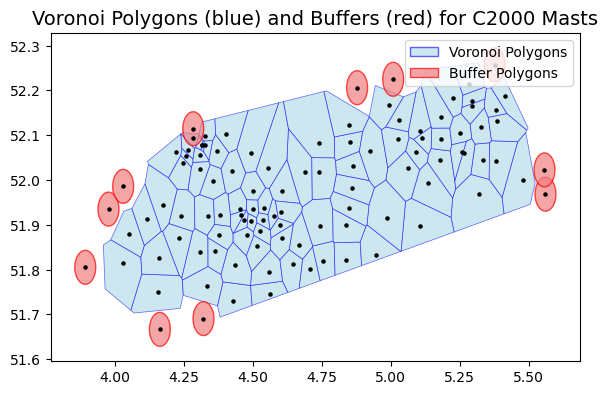

In [13]:
# Create voronoi polygons for c2000_gdf
c2000_gdf, buffer_indices, voronoi_gdf = create_voronoi_coverage(c2000_gdf)

# Create visualization
buffer_polygons_gdf, voronoi_points_gdf_poly = plot_voronoi_coverage(
    c2000_gdf, buffer_indices, title='Voronoi Polygons (blue) and Buffers (red) for C2000 Masts'
)


C:\Users\peregrin\AppData\Local\Temp\ipykernel_5280\61447619.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  mv_points = electrical_data.get('mid_tension_stations').geometry.centroid
C:\Users\peregrin\AppData\Local\Temp\ipykernel_5280\61447619.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  mlv_points = electrical_data.get('mid_low_tension_stations').geometry.centroid
C:\Users\peregrin\AppData\Local\Temp\ipykernel_5280\61447619.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lv_points = electrical_data.get('low_tension_stations').geometry.centroid


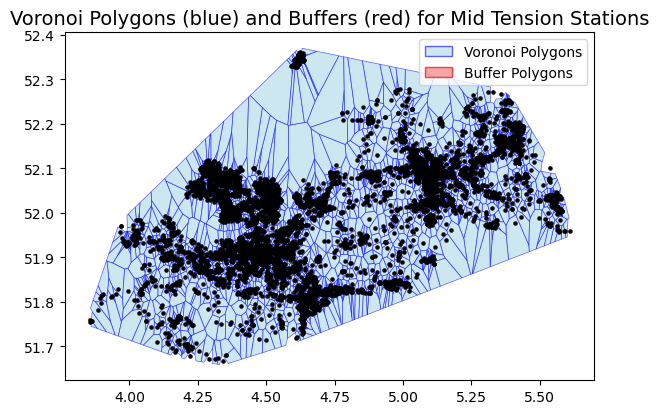

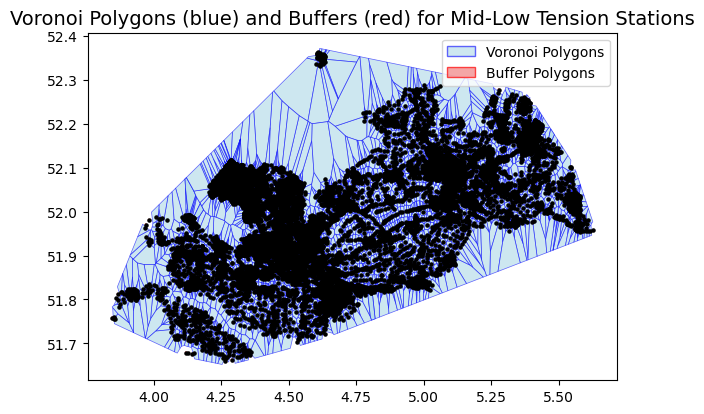

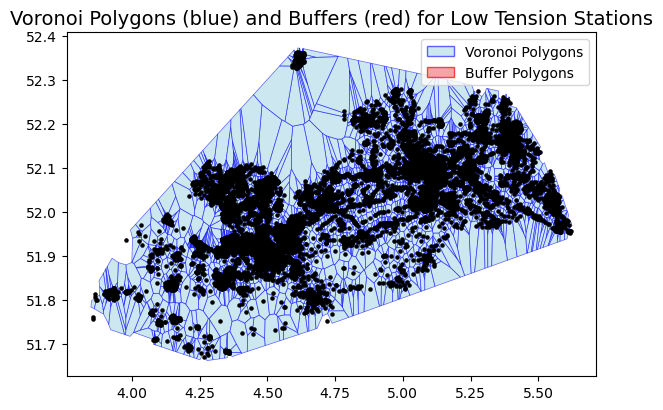

In [14]:
# Find low and mid-low tension station centroids
mv_points = electrical_data.get('mid_tension_stations').geometry.centroid
mlv_points = electrical_data.get('mid_low_tension_stations').geometry.centroid
lv_points = electrical_data.get('low_tension_stations').geometry.centroid

# Create GeoDataFrames of centroids for low and mid-low tension stations
mv_points_gdf = gpd.GeoDataFrame(geometry=mv_points, crs=electrical_data['mid_tension_stations'].crs)
mlv_points_gdf = gpd.GeoDataFrame(geometry=mlv_points, crs=electrical_data['mid_low_tension_stations'].crs)
lv_points_gdf = gpd.GeoDataFrame(geometry=lv_points, crs=electrical_data['low_tension_stations'].crs)

# Create Voronoi polygons for low and mid-low tension stations using centroids
mv_gdf, mv_buffer_indices, mv_voronoi_gdf = create_voronoi_coverage(mv_points_gdf)
mlv_gdf, mlv_buffer_indices, mlv_voronoi_gdf = create_voronoi_coverage(mlv_points_gdf)
lv_gdf, lv_buffer_indices, lv_voronoi_gdf = create_voronoi_coverage(lv_points_gdf)

# Create visualization for low and mid-low tension stations
mv_buffer_polygons_gdf, mv_voronoi_points_gdf_poly = plot_voronoi_coverage(
    mv_gdf, mv_buffer_indices, polygon_col='voronoi_polygon',    
    title='Voronoi Polygons (blue) and Buffers (red) for Mid Tension Stations'
)
mlv_buffer_polygons_gdf, mlv_voronoi_points_gdf_poly = plot_voronoi_coverage(
    mlv_gdf, mlv_buffer_indices, polygon_col='voronoi_polygon',    
    title='Voronoi Polygons (blue) and Buffers (red) for Mid-Low Tension Stations'
)
lv_buffer_polygons_gdf, lv_voronoi_points_gdf_poly = plot_voronoi_coverage(
    lv_gdf, lv_buffer_indices, polygon_col='voronoi_polygon',
    title='Voronoi Polygons (blue) and Buffers (red) for Low Tension Stations'
)



In [15]:
lv_voronoi_points_gdf_poly['asset_type'] = 'lv_station'
mlv_voronoi_points_gdf_poly['asset_type'] = 'mlv_station'
mv_voronoi_points_gdf_poly['asset_type'] = 'mv_station'
voronoi_points_gdf_poly['asset_type'] = 'c2000_mast'

In [16]:
# Function to propagate failures. Takes in a failure cascade as a string, finds the affected assets. 

directly_failed_assets = [('mv_station', 844), ('mlv_station', 3272), ('lv_station', 7117)] # can come from a hazard map

asset_type_dict = {
    'mv_station': mv_voronoi_points_gdf_poly,
    'mlv_station': mlv_voronoi_points_gdf_poly,
    'lv_station': lv_voronoi_points_gdf_poly,
    'c2000_mast': voronoi_points_gdf_poly
}

"test_cascades: mv_station -> mlv_station -> lv_station -> c2000_mast + mv_station -> c2000_mast"
cascades_dict = {
    'mv_station':['mlv_station', 'c2000_mast'],
    'mlv_station':['lv_station'],
    'lv_station':['c2000_mast']
}


In [17]:
def propagate_cascade_from_asset(asset_row, asset_type_dict, cascades_dict, max_depth=5, verbose=True):
    """
    Propagate cascade starting from a single asset row (must have 'asset_type' and index as asset id).
    Returns a dict with affected assets by order and type.
    """
    def _recursive(asset_type, asset_id, order, nth_order_dict):
        # Add the directly failed asset at this order
        if order not in nth_order_dict:
            nth_order_dict[order] = {}
        if asset_type not in nth_order_dict[order]:
            nth_order_dict[order][asset_type] = set()
        nth_order_dict[order][asset_type].add(asset_id)
        # Continue recursion for affected assets
        if order >= max_depth or asset_type not in cascades_dict:
            return
        voronoi_polygon = asset_type_dict[asset_type].loc[asset_id, 'voronoi_polygon']
        for casc_hazard in cascades_dict[asset_type]:
            affected_assets = asset_type_dict[casc_hazard][voronoi_polygon.intersects(asset_type_dict[casc_hazard].geometry)]
            affected_ids = affected_assets.index.tolist()
            if verbose:
                print(f"Order {order+1}: {asset_type} {asset_id} -> {casc_hazard} affected {affected_ids}")
            if (order + 1) not in nth_order_dict:
                nth_order_dict[order + 1] = {}
            if casc_hazard not in nth_order_dict[order + 1]:
                nth_order_dict[order + 1][casc_hazard] = set()
            nth_order_dict[order + 1][casc_hazard].update(affected_ids)
            for idx in affected_ids:
                _recursive(casc_hazard, idx, order + 1, nth_order_dict)

    # Start recursion
    asset_type = asset_row['asset_type']
    asset_id = asset_row.name
    nth_order_dict = {}
    _recursive(asset_type, asset_id, 0, nth_order_dict)
    # Convert sets to sorted lists for easier reading
    for order in nth_order_dict:
        for atype in nth_order_dict[order]:
            nth_order_dict[order][atype] = sorted(nth_order_dict[order][atype])
    return nth_order_dict

# Usage:
# result = propagate_cascade_from_asset(ci_gdf.loc[asset index], asset_type_dict, cascades_dict, max_depth=maximum order, verbose=True for tracing, false for silent)

failed_assets_tree = {}
for asset in directly_failed_assets:
    print(f"Propagating cascade for asset: {asset[0]} {asset[1]}")
    result = propagate_cascade_from_asset(asset_type_dict[asset[0]].loc[asset[1]], asset_type_dict, cascades_dict, max_depth=5, verbose=True)
    failed_assets_tree[asset] = result

print(failed_assets_tree)


Propagating cascade for asset: mv_station 844
Order 1: mv_station 844 -> mlv_station affected [2474, 2429]
Order 2: mlv_station 2474 -> lv_station affected [790, 840]
Order 3: lv_station 790 -> c2000_mast affected [18]
Order 3: lv_station 840 -> c2000_mast affected [18]
Order 2: mlv_station 2429 -> lv_station affected [745, 790, 840]
Order 3: lv_station 745 -> c2000_mast affected [18]
Order 3: lv_station 790 -> c2000_mast affected [18]
Order 3: lv_station 840 -> c2000_mast affected [18]
Order 1: mv_station 844 -> c2000_mast affected [18]
Propagating cascade for asset: mlv_station 3272
Order 1: mlv_station 3272 -> lv_station affected [1159, 1175]
Order 2: lv_station 1159 -> c2000_mast affected [24]
Order 2: lv_station 1175 -> c2000_mast affected [24]
Propagating cascade for asset: lv_station 7117
Order 1: lv_station 7117 -> c2000_mast affected []
{('mv_station', 844): {0: {'mv_station': [844]}, 1: {'mlv_station': [2429, 2474], 'c2000_mast': [18]}, 2: {'lv_station': [745, 790, 840]}, 3: 

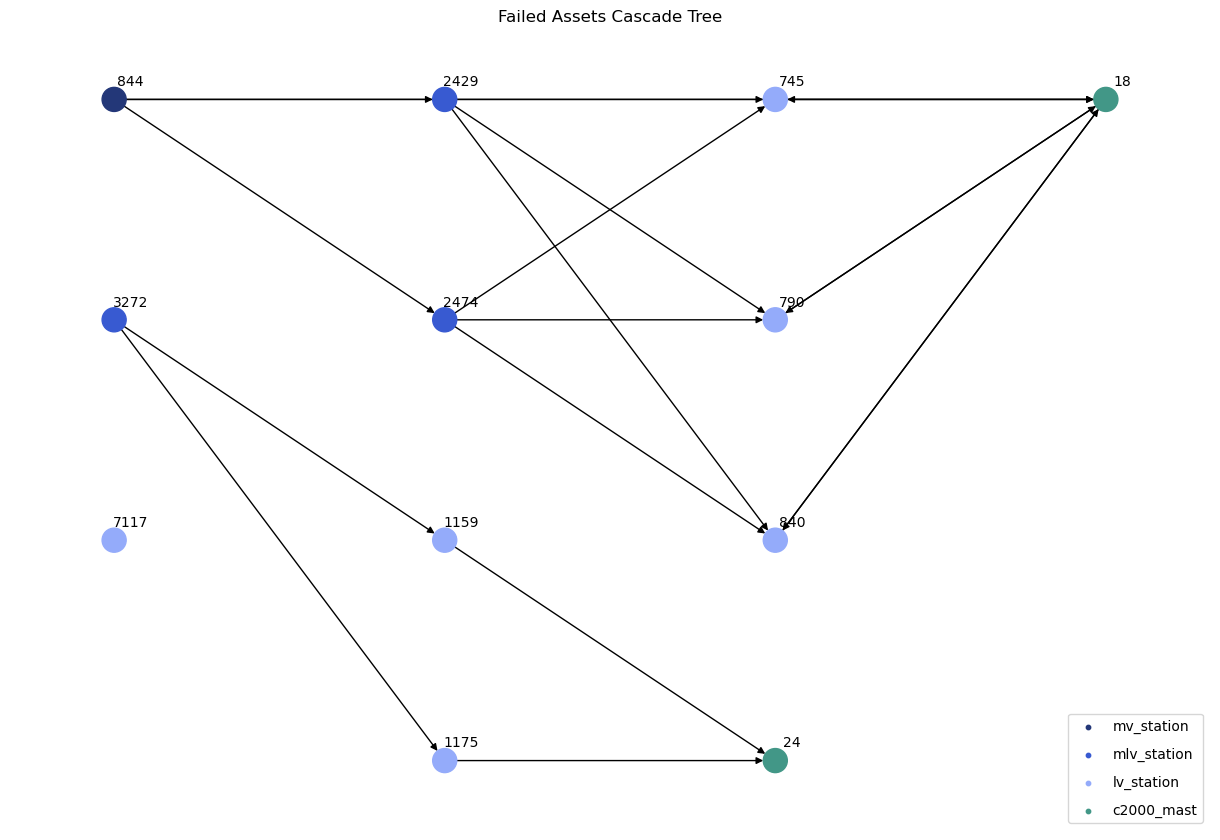

In [18]:
# Visualize the failed assets tree
asset_type_colors = {
            'mv_station': miraca_colors['blue_900'],
            'mlv_station': miraca_colors['blue_600'],
            'lv_station': miraca_colors['blue_300'],
            'c2000_mast': miraca_colors['green_900']
        }
# Visualize the failed assets tree
plot_failed_assets_tree(failed_assets_tree, asset_type_colors=asset_type_colors)


In [19]:
mv_voronoi_points_gdf_poly

,geometry,voronoi_polygon,asset_type
5639,POINT (4.3431 51.668),"POLYGON ((5.1115 52.09, 5.1107 52.089, 5.1095 ...",mv_station
1017,POINT (4.3148 51.671),"POLYGON ((4.5395 51.868, 4.5377 51.859, 4.5346...",mv_station
4049,POINT (4.2911 51.672),"POLYGON ((5.5653 52.038, 5.5683 52.042, 5.5701...",mv_station
844,POINT (4.3255 51.674),"POLYGON ((4.5141 51.844, 4.512 51.843, 4.5118 ...",mv_station
4157,POINT (4.2221 51.679),"POLYGON ((4.2601 52.042, 4.2661 52.042, 4.2664...",mv_station
...,...,...,...
4085,None,"POLYGON ((4.5092 52.039, 4.5104 52.039, 4.5104...",mv_station
6410,None,"POLYGON ((5.0055 52.148, 5.0008 52.144, 5 52.1...",mv_station
6882,None,"POLYGON ((4.8799 52.209, 4.8804 52.209, 4.8808...",mv_station
7001,None,"POLYGON ((5.2309 52.236, 5.2326 52.241, 5.2348...",mv_station


In [20]:
print(mv_voronoi_points_gdf_poly)

                   geometry  \
5639  POINT (4.3431 51.668)   
1017  POINT (4.3148 51.671)   
4049  POINT (4.2911 51.672)   
844   POINT (4.3255 51.674)   
4157  POINT (4.2221 51.679)   
...                     ...   
4085                   None   
6410                   None   
6882                   None   
7001                   None   
7091                   None   

                                        voronoi_polygon  asset_type  
5639  POLYGON ((5.1115 52.09, 5.1107 52.089, 5.1095 ...  mv_station  
1017  POLYGON ((4.5395 51.868, 4.5377 51.859, 4.5346...  mv_station  
4049  POLYGON ((5.5653 52.038, 5.5683 52.042, 5.5701...  mv_station  
844   POLYGON ((4.5141 51.844, 4.512 51.843, 4.5118 ...  mv_station  
4157  POLYGON ((4.2601 52.042, 4.2661 52.042, 4.2664...  mv_station  
...                                                 ...         ...  
4085  POLYGON ((4.5092 52.039, 4.5104 52.039, 4.5104...  mv_station  
6410  POLYGON ((5.0055 52.148, 5.0008 52.144, 5 52.1...  mv_station